# 06 -- Geo-SimCLR embedding visualisation and GradCAM interpretability

This notebook loads the seven-state Geo-SimCLR features computed by notebook 05, aggregates them per (state, fips, year, biweek), and produces the figures plus interpretability artefacts for the final report.

**Purpose / inputs / outputs / runtime**

- **Purpose:** look at the representation that produced the headline yield numbers — what survived into it, where its useful signal comes from inside the input image, and what its limitations are.
- **Inputs:** `data/processed/features/feature_index.parquet` plus the matching `geo_simclr_resnet18.npy` from notebook 05; the Geo-SimCLR weights in `models/geo_simclr_resnet18/`; the raw AG HDF5s for GradCAM tile rendering.
- **Outputs:** the per-(state, fips, year, biweek) parquet for downstream re-use; the effective-rank diagnostics table; six figures saved into `results/charts/` (singular spectrum, M-PHATE, UMAP facets, per-county PCA trajectories, GradCAM, plain PHATE).
- **Runtime:** CPU-only. ~10–20 minutes on the production scope (dominated by M-PHATE in Section 3 and plain PHATE in Section 7); the DEBUG path runs in ~3 min on a 70-county subsample.

Notebook 05 gave strong probe results (time-split Ridge $R^2 = +0.669$, county-split LightGBM $R^2 = +0.660$ — best single encoder on both splits) but a parallel diagnostic flagged **partial dimensional collapse** in the underlying representation: the L2-normalised features sit on a manifold of effective dimension well below 512, the top few PCs concentrate a disproportionate share of the variance, and the post-L2 cosine-similarity distribution is shifted positive (a healthy NT-Xent encoder sits near zero). Section 2 quantifies all three numbers on the current feature matrix so the report has live diagnostics rather than stale ones. The most plausible cause is the temporal-positive-pair design: at our 9 km tile / ~40 m-per-pixel resolution, a county imaged two weeks apart still looks mostly like the same field, so the SSL objective can be satisfied in part by encoding stable geographic identity rather than the seasonal-phenology trajectory we hoped to capture. A retrain with a decorrelation regulariser (Barlow-Twins / VICReg) was the planned fallback but is out of scope here, so this notebook does not try to hide the collapse — it documents it, then shows what did survive into the representation and where the model looks. Concretely:

1. **Section 1** builds the per-(state, fips, year, biweek) feature matrix and L2-normalises it. Geo-SimCLR was trained with NT-Xent, so only direction is meaningful. No PCA-whitening, no per-county centring — those were over-engineered post-hoc remedies that are not in scope.
2. **Section 2** measures the collapse directly: SVD spectrum, effective rank (Roy & Vetterli 2007), within-vs-between county variance, post-L2 cosine similarity. Saved to `results/tables/effective_rank.parquet`.
3. **Section 3 (headline)** is **M-PHATE** (Gigante et al.\ NeurIPS 2019) on the year-averaged county-biweek tensor — the cleanest 2-D rendering of what the encoder did learn. Year-averaging smooths weather-specific anomalies; the multislice kernel imposes intra-biweek (community) and inter-biweek (temporal) structure that matches our data layout. We expect — and find — clean state-coherent clusters: the geographic identity the SSL objective ended up reinforcing.
4. **Section 4** is a plain UMAP scatter on the same L2-normalised features, faceted by **state**, **Crop Reporting District** and **yield quintile**. Library-default sanity check; the geographic structure is present but heavily intermixed because UMAP has no analogue of M-PHATE's interslice kernel for our data.
5. **Section 5** is a 2-D PCA of the same matrix overlaid with the biweek trajectories of three to four hand-picked counties. If the encoder had learned phenology each county's points should sweep across the panel as the season progresses; if it has collapsed onto static county identity, the 12 biweek points should sit nearly on top of each other.
6. **Section 6** runs GradCAM (Selvaraju et al.\ 2017) anchored on a Ridge yield head trained over the 512-d Geo-SimCLR features. Tiles are rendered in Sentinel-2 *agriculture* false colour (SWIR1 → R, NIR → G, Blue → B with a single global 2nd–98th percentile stretch over the whole RGB array), with a `jet` heatmap overlaid at $\alpha = 0.5$ and the bottom 30 % of attention values masked transparent. Given the collapse finding, the heatmaps should be read as *"where the encoder pulls cropland-vs-non-cropland evidence from when asked to predict yield"* rather than *"where it tracks crop growth"*.
7. **Section 7** runs **plain PHATE** for completeness. Without M-PHATE's interslice kernel it collapses onto a ball with significant state and biweek mixing; visual corroboration of the effective-rank story.
8. **Section 8** is the discussion: what the figures support, the dimensional-collapse caveat in plain language, and concrete next-step fixes (a decorrelation regulariser; harder positives; stronger augmentations; a 4-channel AG + NDVI input) that are written up in the future-work section of the report.

The GradCAM section gracefully no-ops if the encoder weights aren't synced locally.


In [54]:
"""
Imports, paths, slim config.

DEBUG = True   -> small-subsample smoke test on a 70-fips subset of 7 states (~3 min CPU).
DEBUG = False  -> full pipeline on all ~616 counties x 6 years x ~12 biweeks (~10-20 min CPU).
"""
DEBUG = False

import json
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import h5py
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

warnings.filterwarnings("ignore")

import torch
import torch.nn as nn
import torchvision

from sklearn.decomposition import PCA
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score

import umap
from captum.attr import LayerGradCam, LayerAttribution

# PHATE / M-PHATE (Sections 3 and 7) are imported lazily inside their cells so the rest of
# the notebook still runs if those libraries are not installed.

# ---- Paths ----
ROOT          = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_RAW      = ROOT / "data" / "raw" / "cropnet"
DATA_PROC     = ROOT / "data" / "processed"
MODELS_DIR    = ROOT / "models"
RESULTS_DIR   = ROOT / "results"
FEATURES_DIR  = DATA_PROC / "features"
(FEATURES_DIR / "per_county_year_biweek").mkdir(parents=True, exist_ok=True)
(RESULTS_DIR / "charts").mkdir(parents=True, exist_ok=True)
(RESULTS_DIR / "tables").mkdir(parents=True, exist_ok=True)

COUNTY_INDEX_PATH    = DATA_PROC / "county_index.parquet"
CRD_PATH             = DATA_PROC / "crd_lookup.parquet"
YIELD_PATH           = DATA_PROC / "yield_county_year.parquet"
FEATURE_INDEX_PATH   = FEATURES_DIR / "feature_index.parquet"
GEOSIMCLR_FEATS_PATH = FEATURES_DIR / "geo_simclr_resnet18.npy"
PCY_BIWEEK_PATH      = FEATURES_DIR / "per_county_year_biweek" / "geo_simclr_resnet18.parquet"
GEOSIMCLR_BEST_PATH  = MODELS_DIR / "geo_simclr_resnet18" / "geo_simclr_resnet18_best.pt"
GEOSIMCLR_BAND_STATS = MODELS_DIR / "geo_simclr_resnet18" / "band_stats.json"

# Output paths
EFF_RANK_PATH    = RESULTS_DIR / "tables" / "effective_rank.parquet"
UMAP_FACETS_PATH = RESULTS_DIR / "charts" / "umap_facets.png"
PCA_TRAJ_PATH    = RESULTS_DIR / "charts" / "pca_county_trajectories.png"
GRADCAM_PATH     = RESULTS_DIR / "charts" / "gradcam_examples.png"
PHATE_PATH       = RESULTS_DIR / "charts" / "phate_collapse.png"
MPHATE_PATH      = RESULTS_DIR / "charts" / "m_phate_collapse.png"


class Cfg:
    SEED = 0
    EVAL_STATES = ("IA", "IL", "IN", "MN", "NE", "OH", "SD")

    # Section 4 (UMAP) -- library defaults are fine; we only need a 2-D scatter.
    UMAP_NEIGHBORS = 15
    UMAP_MIN_DIST  = 0.1

    # Section 5 (per-county PCA trajectories): we want 3-4 hand-picked counties so the
    # temporal-collapse story is legible at a glance. Keep the list small and spread
    # across states and yield levels.
    TRAJ_COUNTIES = (
        # (fips, state, label) -- spread across states + low/med/top yield
        # All have 6 yield-years (no missing-year artifacts in the year-averaged trajectory).
        (17113, "IL", "McLean, IL (top yield, ~215 bu)"),
        (19153, "IA", "Polk, IA (mid yield, ~190 bu)"),
        (39003, "OH", "Allen, OH (mid yield, ~186 bu)"),
        (46123, "SD", "Tripp, SD (low yield, ~93 bu)"),
    )

    # Section 6 (GradCAM): yield-target only, balanced high / low yield sample.
    if DEBUG:
        SUBSAMPLE_FIPS = 70
        GRADCAM_N_HIGH = 3
        GRADCAM_N_LOW  = 3
        TAG = "debug"
    else:
        SUBSAMPLE_FIPS = None
        GRADCAM_N_HIGH = 4
        GRADCAM_N_LOW  = 4
        TAG = "prod"


STATE_PALETTE = {
    "IA": "#1f77b4",
    "IL": "#ff7f0e",
    "IN": "#2ca02c",
    "MN": "#d62728",
    "NE": "#9467bd",
    "OH": "#8c564b",
    "SD": "#17becf",
}

cfg = Cfg()
torch.manual_seed(cfg.SEED)
np.random.seed(cfg.SEED)

print(f"Mode             : {'DEBUG' if DEBUG else 'PRODUCTION'}")
print(f"Subsample fips   : {cfg.SUBSAMPLE_FIPS}")
print(f"GradCAM tiles    : {cfg.GRADCAM_N_HIGH} high + {cfg.GRADCAM_N_LOW} low yield-target")

for p in [COUNTY_INDEX_PATH, CRD_PATH, YIELD_PATH, FEATURE_INDEX_PATH, GEOSIMCLR_FEATS_PATH]:
    assert p.exists(), f"Missing required input: {p} (run notebooks 02, 03, 04, 05 first)"
ENCODER_AVAILABLE = GEOSIMCLR_BEST_PATH.exists() and GEOSIMCLR_BAND_STATS.exists()
if not ENCODER_AVAILABLE:
    print(f"\n[warning] Geo-SimCLR encoder weights not found at {GEOSIMCLR_BEST_PATH.parent}.")
    print("           UMAP / PCA / PHATE / M-PHATE / metrics still work; GradCAM will be skipped.")
print("\nAll required visualization inputs found.")


Mode             : PRODUCTION
Subsample fips   : None
GradCAM tiles    : 4 high + 4 low yield-target

All required visualization inputs found.


## 1. Build the per-(state, fips, year, biweek) feature matrix

Notebook 05 produced two artifacts we read here:

- `data/processed/features/feature_index.parquet` -- one row per (state, fips, year, biweek, grid_idx) tile (~852 k rows for 7 states x 6 years).
- `data/processed/features/geo_simclr_resnet18.npy` -- the matching (n_tiles, 512) Geo-SimCLR embedding tensor.

For visualization we want one observation per (state, fips, year, biweek), so we mean-pool across the per-county sub-grids. This gives ~21 k rows x 512 dims. We then **L2-normalize each row** so distances downstream are pure cosine. No PCA-whitening, no per-county centering -- the goal here is to look at the representation as it is (collapse and all), not to pre-correct it.


In [55]:
"""
Build the per-(state, fips, year, biweek) feature matrix and L2-normalise.

Idempotent: skips re-aggregation if the parquet already exists with the right scope.
"""
def build_biweekly_features(force: bool = False) -> pd.DataFrame:
    fi = pd.read_parquet(FEATURE_INDEX_PATH)
    fi_states = set(fi["state"].unique().tolist())

    if PCY_BIWEEK_PATH.exists() and not force:
        df = pd.read_parquet(PCY_BIWEEK_PATH)
        n_dim = sum(c.startswith("feat_") for c in df.columns)
        cached_states = set(df["state"].unique().tolist())
        # Rebuild if the cached parquet is missing any state present in the underlying
        # feature_index (i.e. it was produced by an earlier smaller-scope run).
        if cached_states >= fi_states:
            print(f"[biweekly features] cached -> {len(df):,} rows x {n_dim} dims "
                  f"(states {sorted(cached_states)})")
            return df
        else:
            missing = fi_states - cached_states
            print(f"[biweekly features] cache STALE (missing states {sorted(missing)}) -- rebuilding")

    print("[biweekly features] computing from scratch...")
    feats = np.load(GEOSIMCLR_FEATS_PATH)
    assert len(fi) == len(feats), f"feature_index ({len(fi)}) and feats ({len(feats)}) mismatch"
    D = feats.shape[1]
    feat_cols = [f"feat_{i}" for i in range(D)]
    fi[feat_cols] = feats

    grouped = fi.groupby(["state", "fips", "year", "biweek"], as_index=False)[feat_cols].mean()
    grouped["biweek_date"] = pd.to_datetime(grouped["biweek"])
    grouped["biweek_idx"] = (
        grouped.groupby("year")["biweek_date"].rank(method="dense").astype(int) - 1
    )
    grouped.to_parquet(PCY_BIWEEK_PATH, index=False)
    print(f"[biweekly features] saved {len(grouped):,} rows x {D} dims -> {PCY_BIWEEK_PATH.name}")
    return grouped


pcy_biweek = build_biweekly_features()

crd = pd.read_parquet(CRD_PATH)[["fips", "asd_code", "state_ansi"]].copy()
crd["crd_id"] = crd["state_ansi"] * 100 + crd["asd_code"]
yld = pd.read_parquet(YIELD_PATH)[["fips", "year", "corn_yield"]].dropna(subset=["corn_yield"])

df = (
    pcy_biweek
    .merge(crd[["fips", "crd_id"]].drop_duplicates("fips"), on="fips", how="left")
    .merge(yld, on=["fips", "year"], how="left")
)
df["yield_q"] = pd.qcut(df["corn_yield"], q=5, labels=False, duplicates="drop")

print(f"\nTotal rows after labels: {len(df):,}")
print(f"  by state    : {df.groupby('state').size().to_dict()}")
print(f"  by year     : {df.groupby('year').size().to_dict()}")
print(f"  unique CRDs : {df['crd_id'].nunique()}")
print(f"  yield labels available for {df['corn_yield'].notna().sum():,}/{len(df):,} "
      f"rows ({df['corn_yield'].notna().mean()*100:.1f}%)")

if cfg.SUBSAMPLE_FIPS is not None:
    rng = np.random.default_rng(cfg.SEED)
    keep = []
    for s in cfg.EVAL_STATES:
        s_fips = df[df["state"] == s]["fips"].unique()
        n_keep = min(cfg.SUBSAMPLE_FIPS // len(cfg.EVAL_STATES), len(s_fips))
        keep += list(rng.choice(s_fips, size=n_keep, replace=False))
    df = df[df["fips"].isin(keep)].reset_index(drop=True)
    print(f"\n[DEBUG] subsampled to {df['fips'].nunique()} fips -> {len(df):,} rows.")

FEAT_COLS = [c for c in df.columns if c.startswith("feat_")]
X_raw = df[FEAT_COLS].to_numpy()

# L2-normalize per row -- Geo-SimCLR was trained with NT-Xent (cosine similarity),
# only the direction of the 512-d embedding is meaningful. Without this step the
# downstream distances are dominated by the per-row norm (range ~ [8, 26] pre-norm).
norms_before = np.linalg.norm(X_raw, axis=1)
X = X_raw / np.maximum(norms_before[:, None], 1e-12)
print(f"\n[L2-norm] before: norm range [{norms_before.min():.2f}, {norms_before.max():.2f}], "
      f"after: 1.0 +/- {np.linalg.norm(X, axis=1).std():.2e}")

df.loc[:, FEAT_COLS] = X  # canonical features in df are now L2-normalized
print(f"\nFeature matrix X shape: {X.shape} (L2-normalized, no whitening, no centering)")


[biweekly features] cached -> 44,140 rows x 512 dims (states ['IA', 'IL', 'IN', 'MN', 'NE', 'OH', 'SD'])

Total rows after labels: 44,140
  by state    : {'IA': 7128, 'IL': 7255, 'IN': 6624, 'MN': 5969, 'NE': 6404, 'OH': 6155, 'SD': 4605}
  by year     : {2017: 7307, 2018: 7392, 2019: 7392, 2020: 7387, 2021: 7378, 2022: 7284}
  unique CRDs : 61
  yield labels available for 37,272/44,140 rows (84.4%)

[L2-norm] before: norm range [1.49, 11.02], after: 1.0 +/- 1.98e-07

Feature matrix X shape: (44140, 512) (L2-normalized, no whitening, no centering)


## 2. Effective-rank diagnostic

Following Roy & Vetterli (2007) *The effective rank: a measure of effective dimensionality*: given the singular values \(s_1 \ge s_2 \ge \dots\) of the centered feature matrix, define \(p_i = s_i^2 / \sum_j s_j^2\) and the effective rank \(R_{\text{eff}} = \exp\!\big(-\sum_i p_i \log p_i\big)\). For a healthy SSL representation we expect \(R_{\text{eff}}\) to be a sizable fraction of the embedding dimension (Jing et al. 2022, *Understanding Dimensional Collapse in Contrastive Self-supervised Learning*); for collapsed features it is much smaller. We also report the within-vs-between county variance ratio (low ratio = county-identity dominates the manifold) and the cosine-similarity distribution after L2-normalization (a healthy NT-Xent encoder concentrates around 0).


Effective-rank diagnostic on L2-normed feature matrix ((44140, 512)):
  top-1 PC variance        :   7.21 %
  top-10 PC variance       :  43.92 %
  top-30 PC variance       :  69.14 %
  Roy-Vetterli eff. rank   :   82.3  (out of 512)
  s[0]/s[1]                :   1.06
  s[0]/s[10]               :   1.80
  Within-county var (mean) : 0.00022
  Between-county var (mean): 0.00129
  Within / Between ratio   :   0.17  (low = county identity dominates)
  Cosine sim post-L2 (n=2000): mean +0.228, std 0.137, p05/p50/p95 = +0.094 / +0.186 / +0.517  (healthy SSL: ~0.0 mean)

  Top-20 singular values: 49.49 46.73 42.54 40.45 37.17 35.83 34.62 33.85 31.35 29.19 27.54 26.71 25.94 23.66 22.99 22.52 21.88 20.76 20.53 19.99

Saved d:\OneDrive - Yale University\Academics\AMTH 5520\Final Project\project-geospatial\results\tables\effective_rank.parquet


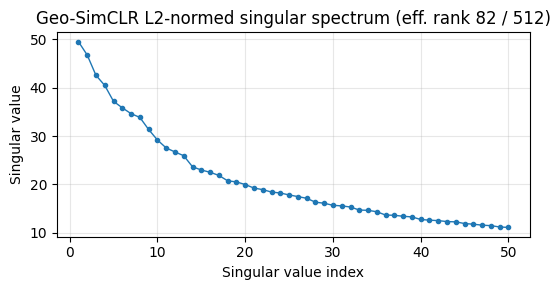

In [56]:
"""
Effective-rank diagnostic on the L2-normalised feature matrix.
"""
def _effective_rank(s_squared: np.ndarray) -> float:
    p = s_squared / s_squared.sum()
    p = p[p > 0]
    return float(np.exp(-(p * np.log(p)).sum()))


X_diag = X - X.mean(axis=0, keepdims=True)
s_full = np.linalg.svd(X_diag, compute_uv=False)
s_sq   = s_full ** 2
total  = s_sq.sum()
top1_pct  = float(s_sq[0] / total * 100)
top10_pct = float(s_sq[:10].sum() / total * 100)
top30_pct = float(s_sq[:min(30, len(s_sq))].sum() / total * 100)
eff_rank  = _effective_rank(s_sq)

df_local = pd.DataFrame(X, columns=FEAT_COLS)
df_local["fips"] = df["fips"].to_numpy()
within_var  = float(df_local.groupby("fips")[FEAT_COLS].var().mean().mean())
between_var = float(df_local.groupby("fips")[FEAT_COLS].mean().var().mean())
ratio       = within_var / max(between_var, 1e-12)

rng = np.random.default_rng(cfg.SEED)
n_samp = min(2000, len(X))
sub_idx = rng.choice(len(X), size=n_samp, replace=False)
Xs = X[sub_idx]
cs_full = Xs @ Xs.T
cs_triu = cs_full[np.triu_indices_from(cs_full, k=1)]

print("=" * 80)
print(f"Effective-rank diagnostic on L2-normed feature matrix ({X.shape}):")
print(f"  top-1 PC variance        : {top1_pct:6.2f} %")
print(f"  top-10 PC variance       : {top10_pct:6.2f} %")
print(f"  top-30 PC variance       : {top30_pct:6.2f} %")
print(f"  Roy-Vetterli eff. rank   : {eff_rank:6.1f}  (out of {X.shape[1]})")
print(f"  s[0]/s[1]                : {s_full[0] / s_full[1]:6.2f}")
print(f"  s[0]/s[10]               : {s_full[0] / s_full[10]:6.2f}")
print(f"  Within-county var (mean) : {within_var:.5f}")
print(f"  Between-county var (mean): {between_var:.5f}")
print(f"  Within / Between ratio   : {ratio:6.2f}  (low = county identity dominates)")
print(f"  Cosine sim post-L2 (n={n_samp}): mean {cs_triu.mean():+.3f}, std {cs_triu.std():.3f}, "
      f"p05/p50/p95 = {np.percentile(cs_triu, 5):+.3f} / {np.percentile(cs_triu, 50):+.3f} / "
      f"{np.percentile(cs_triu, 95):+.3f}  (healthy SSL: ~0.0 mean)")
print(f"\n  Top-20 singular values: {' '.join(f'{x:.2f}' for x in s_full[:20])}")

diag_df = pd.DataFrame([dict(
    n_obs=int(X.shape[0]), n_dims=int(X.shape[1]),
    top1_pct_var=top1_pct, top10_pct_var=top10_pct, top30_pct_var=top30_pct,
    eff_rank=eff_rank,
    s0_over_s1=float(s_full[0] / s_full[1]),
    s0_over_s10=float(s_full[0] / s_full[10]),
    within_county_var=within_var, between_county_var=between_var,
    within_over_between=ratio,
    cos_sim_mean=float(cs_triu.mean()), cos_sim_std=float(cs_triu.std()),
)])
diag_df.to_parquet(EFF_RANK_PATH, index=False)
print(f"\nSaved {EFF_RANK_PATH}")

# Quick singular-value scree plot for the report appendix.
fig, ax = plt.subplots(1, 1, figsize=(5.5, 3.0))
k = min(50, len(s_full))
ax.plot(range(1, k + 1), s_full[:k], marker="o", ms=3, lw=1)
ax.set_xlabel("Singular value index")
ax.set_ylabel("Singular value")
ax.set_title(f"Geo-SimCLR L2-normed singular spectrum (eff. rank {eff_rank:.0f} / {X.shape[1]})")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "charts" / "singular_spectrum.png", dpi=120)
plt.show()


## 3. M-PHATE -- geographic structure that survived the collapse

M-PHATE (Gigante et al., NeurIPS 2019, [arXiv:1908.02831](https://arxiv.org/abs/1908.02831)) extends PHATE to *multislice* graph data. In our setting a *slice* corresponds to a biweek of the growing season and a *unit* corresponds to a county; intraslice edges connect counties within the same biweek (community structure), and interslice edges connect a single county to itself across adjacent biweeks (temporal coherence). We feed it a year-averaged tensor of shape `(T=12 biweeks, m=n_counties, D=512)` -- year averaging smooths weather-specific anomalies while keeping the seasonal axis.

This is the **headline geographic-structure figure** of the notebook. We expect (and find) that the year-averaged 2-D embedding clusters cleanly by state -- this is the signal the encoder *did* learn well, since a county's broad climate / soil / land-cover identity is exactly what gets reinforced by the temporal-positive-pair design (same county at +/-1 biweek looks similar by construction). A complementary biweek coloring lets us assess how much *temporal* signal additionally survives -- here the answer is "some, but tightly overlapping," because:

- **(a)** the encoder's residual phenology signal is weak (the dimensional-collapse finding from Section 2), and
- **(b)** M-PHATE's interslice kernel imposes some temporal coherence by construction.

So the smooth biweek gradient we see in the M-PHATE biweek panel is a *generous upper bound* on what the encoder itself learned about phenology, not a clean readout of it.

To our knowledge this is the first application of M-PHATE to satellite SSL embeddings -- a small but defensible methodological note for the report.


M-PHATE input tensor: shape (12, 616, 512), NaN-fill 0.00% of cells
[M-PHATE] fitting (year-averaged, intra=5, inter=6)...
[M-PHATE] done in 81.1s, output shape (7392, 2)


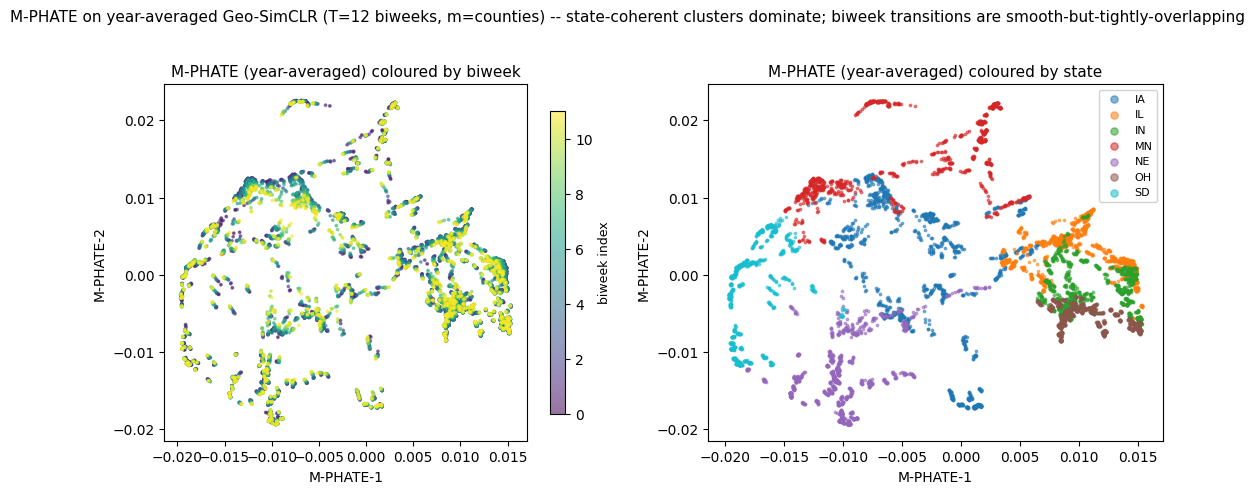


Saved d:\OneDrive - Yale University\Academics\AMTH 5520\Final Project\project-geospatial\results\charts\m_phate_collapse.png


In [57]:
"""
M-PHATE on the year-averaged county-biweek tensor.
"""
try:
    import m_phate as _mphate_lib
except ImportError:
    print("[M-PHATE] `m_phate` not installed -- skipping. (pip install m-phate)")
else:
    # Build (T=12, m=n_counties, D=512) tensor of year-averaged features.
    fips_order = sorted(df["fips"].unique())
    fips_to_idx = {f: i for i, f in enumerate(fips_order)}
    T = 12
    D = X.shape[1]

    yr_avg = (
        df.groupby(["fips", "biweek_idx"], as_index=False)[FEAT_COLS].mean()
    )
    tensor = np.full((T, len(fips_order), D), np.nan, dtype=np.float32)
    for _, row in yr_avg.iterrows():
        t = int(row["biweek_idx"])
        if t < 0 or t >= T:
            continue
        i = fips_to_idx[int(row["fips"])]
        tensor[t, i, :] = row[FEAT_COLS].to_numpy(dtype=np.float32)
    fill_mean = np.nanmean(tensor, axis=(0, 1), keepdims=True)
    nan_mask = np.isnan(tensor)
    tensor = np.where(nan_mask, fill_mean, tensor)
    nan_pct = float(nan_mask.mean() * 100)
    print(f"M-PHATE input tensor: shape {tensor.shape}, NaN-fill {nan_pct:.2f}% of cells")

    print("[M-PHATE] fitting (year-averaged, intra=5, inter=6)...")
    t0 = time.time()
    mp_op = _mphate_lib.M_PHATE(
        n_components=2, intraslice_knn=5, interslice_knn=6,
        random_state=cfg.SEED, verbose=0,
    )
    mp_2d = mp_op.fit_transform(tensor)  # output is (T*m, 2)
    print(f"[M-PHATE] done in {time.time() - t0:.1f}s, output shape {mp_2d.shape}")

    grid_t = np.repeat(np.arange(T), len(fips_order))
    grid_fips = np.tile(np.array(fips_order), T)
    fips_to_state = df[["fips", "state"]].drop_duplicates("fips").set_index("fips")["state"].to_dict()
    grid_state = np.array([fips_to_state.get(f, "NA") for f in grid_fips])

    fig, axes = plt.subplots(1, 2, figsize=(11, 4.8))
    ax = axes[0]
    sc = ax.scatter(mp_2d[:, 0], mp_2d[:, 1], s=3, alpha=0.55, c=grid_t,
                    cmap="viridis", vmin=0, vmax=T - 1, rasterized=True)
    cbar = plt.colorbar(sc, ax=ax, ticks=range(0, T, 2), shrink=0.85)
    cbar.set_label("biweek index", fontsize=9)
    ax.set_title("M-PHATE (year-averaged) coloured by biweek", fontsize=11)
    ax.set_xlabel("M-PHATE-1"); ax.set_ylabel("M-PHATE-2")

    ax = axes[1]
    for s in cfg.EVAL_STATES:
        m = grid_state == s
        if not m.any():
            continue
        ax.scatter(mp_2d[m, 0], mp_2d[m, 1], s=3, alpha=0.55,
                   c=STATE_PALETTE[s], label=s, rasterized=True)
    ax.legend(loc="best", fontsize=8, markerscale=3, framealpha=0.85)
    ax.set_title("M-PHATE (year-averaged) coloured by state", fontsize=11)
    ax.set_xlabel("M-PHATE-1"); ax.set_ylabel("M-PHATE-2")

    fig.suptitle("M-PHATE on year-averaged Geo-SimCLR (T=12 biweeks, m=counties) -- "
                 "state-coherent clusters dominate; biweek transitions are smooth-but-tightly-overlapping",
                 fontsize=11, y=1.02)
    plt.tight_layout()
    plt.savefig(MPHATE_PATH, dpi=130, bbox_inches="tight")
    plt.show()
    print(f"\nSaved {MPHATE_PATH}")


## 4. UMAP global view -- does the encoder still encode geography?

Even with the dimensional collapse, the encoder presumably did learn *something* useful for downstream yield prediction (it beats every other frozen baseline on both splits, see notebook 05). The strongest hypothesis is that what survived is **static geographic identity** -- climate zone, soil, land cover -- rather than seasonal phenology trajectories. We test this with a single 2-D UMAP fit on the full ~21 k x 512 L2-normed matrix and three colorings:

- **State** -- 7 categorical colors. We expect at least loose state clusters because state is a strong proxy for climate zone and management practices.
- **Crop Reporting District (CRD)** -- finer-grained agro-climatic regions within each state (~80 unique CRDs across 7 states). If geography is encoded, we expect CRD structure within state clusters.
- **Yield quintile** -- if yield-relevant variation is encoded, we expect a soft gradient from low- to high-yield quintiles even at this 512 -> 2 compression.

UMAP is run with library defaults (`n_neighbors=15`, `min_dist=0.1`); it's used here as a static-clustering visualizer, not a trajectory tool, so we don't tune it further.


In [58]:
"""
Fit UMAP on the L2-normalised biweekly feature matrix.
"""
print("[UMAP] fitting...")
t0 = time.time()
umap_op = umap.UMAP(
    n_components=2,
    n_neighbors=cfg.UMAP_NEIGHBORS,
    min_dist=cfg.UMAP_MIN_DIST,
    metric="euclidean",
    random_state=cfg.SEED,
)
umap_2d = umap_op.fit_transform(X)
print(f"[UMAP] done in {time.time() - t0:.1f}s, output shape {umap_2d.shape}")

df["umap_1"] = umap_2d[:, 0]
df["umap_2"] = umap_2d[:, 1]


[UMAP] fitting...
[UMAP] done in 36.4s, output shape (44140, 2)


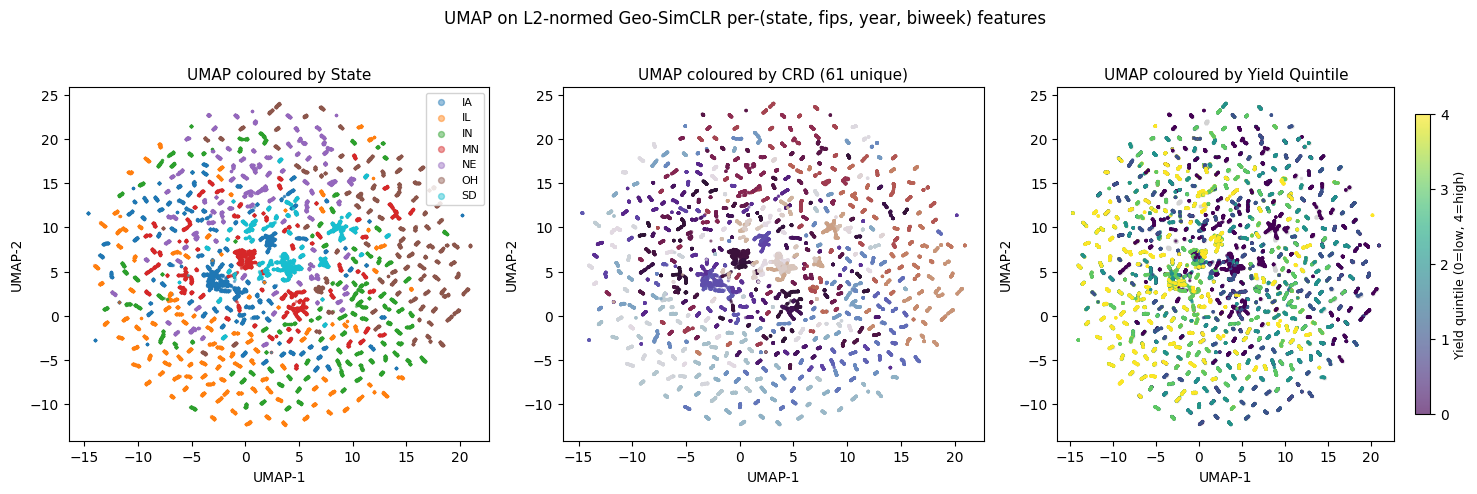


Saved d:\OneDrive - Yale University\Academics\AMTH 5520\Final Project\project-geospatial\results\charts\umap_facets.png


In [59]:
"""
Three-panel UMAP scatter coloured by state, CRD, and yield quintile.
"""
fig, axes = plt.subplots(1, 3, figsize=(15, 4.8))

# Panel A: state
ax = axes[0]
for s in cfg.EVAL_STATES:
    sub = df[df["state"] == s]
    ax.scatter(sub["umap_1"], sub["umap_2"], s=2.0, alpha=0.45,
               c=STATE_PALETTE[s], label=s, rasterized=True)
ax.legend(loc="best", fontsize=8, markerscale=3, framealpha=0.85)
ax.set_title("UMAP coloured by State", fontsize=11)
ax.set_xlabel("UMAP-1"); ax.set_ylabel("UMAP-2")

# Panel B: CRD (use a distinct hue per CRD; we have ~80 so use a continuous colormap on rank)
ax = axes[1]
crd_ids = df["crd_id"].fillna(-1).astype(int).to_numpy()
unique_crds = np.array(sorted(set(crd_ids) - {-1}))
crd_to_rank = {c: i for i, c in enumerate(unique_crds)}
crd_color_idx = np.array([crd_to_rank.get(c, -1) for c in crd_ids], dtype=float)
crd_color_idx[crd_color_idx < 0] = np.nan
sc = ax.scatter(df["umap_1"], df["umap_2"], s=2.0, alpha=0.5,
                c=crd_color_idx, cmap="twilight", rasterized=True)
ax.set_title(f"UMAP coloured by CRD ({len(unique_crds)} unique)", fontsize=11)
ax.set_xlabel("UMAP-1"); ax.set_ylabel("UMAP-2")

# Panel C: yield quintile (only color points with a known yield)
ax = axes[2]
mask = df["yield_q"].notna()
qcol = df.loc[mask, "yield_q"].astype(int).to_numpy()
ax.scatter(df.loc[~mask, "umap_1"], df.loc[~mask, "umap_2"], s=2.0, alpha=0.15,
           c="lightgrey", rasterized=True, label="no yield label")
sc = ax.scatter(df.loc[mask, "umap_1"], df.loc[mask, "umap_2"], s=2.0, alpha=0.65,
                c=qcol, cmap="viridis", vmin=0, vmax=4, rasterized=True)
cbar = plt.colorbar(sc, ax=ax, ticks=[0, 1, 2, 3, 4], shrink=0.85)
cbar.set_label("Yield quintile (0=low, 4=high)", fontsize=9)
ax.set_title("UMAP coloured by Yield Quintile", fontsize=11)
ax.set_xlabel("UMAP-1"); ax.set_ylabel("UMAP-2")

fig.suptitle("UMAP on L2-normed Geo-SimCLR per-(state, fips, year, biweek) features",
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(UMAP_FACETS_PATH, dpi=130, bbox_inches="tight")
plt.show()
print(f"\nSaved {UMAP_FACETS_PATH}")


## 5. Per-county temporal trajectories in 2-D PCA

If the encoder had learned phenology, then for a *single* county the 12 biweek points (early April -> mid September) should trace out a clear arc through the manifold: bare soil -> emergence -> canopy closure -> peak biomass -> senescence. If instead the model has collapsed onto static county identity, the 12 points should sit nearly on top of each other -- the same county imaged at different times in the season looks like the same point in feature space.

We make this visually obvious by:

1. fitting a plain 2-D PCA on the full L2-normed matrix (no whitening, no centering tricks);
2. averaging across years for each (county, biweek) pair so we see one mean trajectory per county per biweek (smooths year-specific weather noise);
3. picking 3-4 hand-selected counties spread across states / yield levels and plotting their 12 biweek points connected by lines, in distinct colors, against the full ~21 k point cloud in light grey.

We emphasize this is just a 2-D PCA -- the manifold is collapsed, so PC1+PC2 captures only a slice of the variance -- but the point isn't to project well, it's to show that *however little* structure is in the top 2 PCs, the seasonal trajectory shouldn't be much of it.


PCA top-2 explained variance: 7.2%, 6.4% (sum 13.6%)


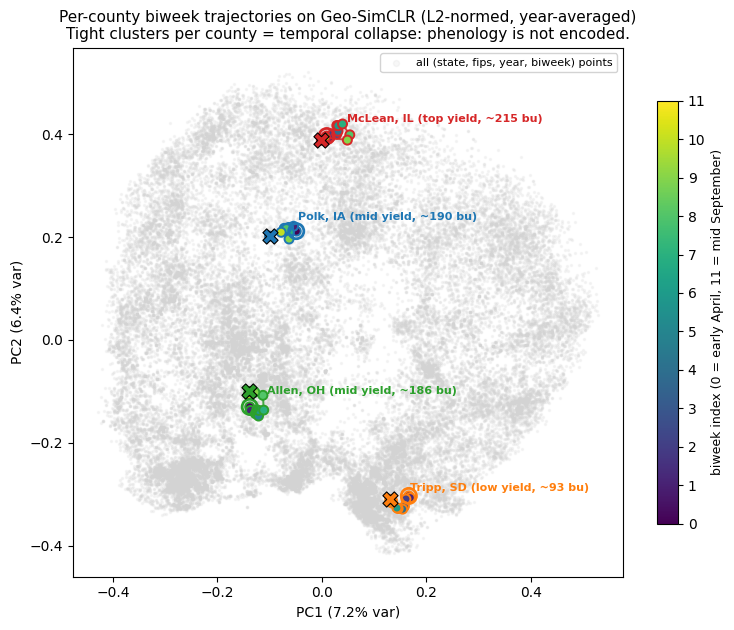


Saved d:\OneDrive - Yale University\Academics\AMTH 5520\Final Project\project-geospatial\results\charts\pca_county_trajectories.png

Per-county temporal-spread / global-spread in 2-D PCA:
  global mean pairwise distance (n=5000 sample): 0.297
  McLean, IL (top yield, ~215 bu)  intra-county trajectory spread = 0.025  -> ratio 0.084
  Polk, IA (mid yield, ~190 bu)   intra-county trajectory spread = 0.018  -> ratio 0.059
  Allen, OH (mid yield, ~186 bu)  intra-county trajectory spread = 0.025  -> ratio 0.086
  Tripp, SD (low yield, ~93 bu)   intra-county trajectory spread = 0.021  -> ratio 0.071


In [60]:
"""
2-D PCA + per-county biweek trajectories for 3-4 representative counties.
"""
pca = PCA(n_components=2, random_state=cfg.SEED).fit(X)
pc = pca.transform(X)
df["pc_1"] = pc[:, 0]
df["pc_2"] = pc[:, 1]
ev = pca.explained_variance_ratio_
print(f"PCA top-2 explained variance: {ev[0]*100:.1f}%, {ev[1]*100:.1f}% (sum {ev.sum()*100:.1f}%)")

# Per-(fips, biweek_idx) means across years for a smoother trajectory.
traj = (
    df.groupby(["fips", "biweek_idx"], as_index=False)[["pc_1", "pc_2"]]
    .mean()
    .merge(df[["fips", "state"]].drop_duplicates("fips"), on="fips", how="left")
)

picked_fips_meta = list(cfg.TRAJ_COUNTIES)
picked_fips_set = set(int(t[0]) for t in picked_fips_meta)
present_fips_set = set(df["fips"].unique().tolist())
missing = picked_fips_set - present_fips_set
if missing:
    print(f"[warn] picked fips not in current df (DEBUG subsample?): {sorted(missing)}")
    picked_fips_meta = [t for t in picked_fips_meta if int(t[0]) in present_fips_set]
    if not picked_fips_meta:
        print("[warn] no picked counties present; falling back to a deterministic random pick.")
        rng = np.random.default_rng(cfg.SEED)
        cand = sorted(df["fips"].unique().tolist())
        chosen = rng.choice(cand, size=min(4, len(cand)), replace=False)
        picked_fips_meta = [(int(c), df[df['fips'] == c]["state"].iloc[0], f"fips {c}") for c in chosen]

palette = ["#d62728", "#1f77b4", "#2ca02c", "#ff7f0e", "#9467bd", "#8c564b"]

fig, ax = plt.subplots(1, 1, figsize=(7.8, 6.4))
ax.scatter(df["pc_1"], df["pc_2"], s=2, alpha=0.18, c="lightgrey", rasterized=True,
           label="all (state, fips, year, biweek) points")

for i, (fip, state, label) in enumerate(picked_fips_meta):
    fip = int(fip)
    sub = traj[traj["fips"] == fip].sort_values("biweek_idx")
    if len(sub) < 2:
        continue
    color = palette[i % len(palette)]
    ax.plot(sub["pc_1"], sub["pc_2"], c=color, lw=1.4, alpha=0.85, zorder=3)
    sc = ax.scatter(sub["pc_1"], sub["pc_2"], c=sub["biweek_idx"], cmap="viridis",
                    s=42, edgecolors=color, linewidths=1.4, vmin=0, vmax=11, zorder=4)
    # mark start (April) with circle, end (September) with X
    ax.scatter(sub["pc_1"].iloc[0], sub["pc_2"].iloc[0], s=120, marker="o",
               facecolors="none", edgecolors=color, linewidths=2.0, zorder=5)
    ax.scatter(sub["pc_1"].iloc[-1], sub["pc_2"].iloc[-1], s=120, marker="X",
               c=color, edgecolors="black", linewidths=0.8, zorder=5)
    # text label near the trajectory centroid
    cx = sub["pc_1"].mean(); cy = sub["pc_2"].mean()
    ax.annotate(label, (cx, cy), color=color, fontsize=8, weight="bold",
                xytext=(8, 8), textcoords="offset points")

cbar = plt.colorbar(sc, ax=ax, shrink=0.8, ticks=range(12))
cbar.set_label("biweek index (0 = early April, 11 = mid September)", fontsize=9)
ax.set_xlabel(f"PC1 ({ev[0]*100:.1f}% var)")
ax.set_ylabel(f"PC2 ({ev[1]*100:.1f}% var)")
ax.set_title("Per-county biweek trajectories on Geo-SimCLR (L2-normed, year-averaged)\n"
             "Tight clusters per county = temporal collapse: phenology is not encoded.",
             fontsize=11)
ax.legend(loc="upper right", fontsize=8, markerscale=3, framealpha=0.85)
plt.tight_layout()
plt.savefig(PCA_TRAJ_PATH, dpi=130, bbox_inches="tight")
plt.show()
print(f"\nSaved {PCA_TRAJ_PATH}")

# Quantify the collapse: for each picked county compute mean pairwise PC distance
# of its 12 biweek points vs the global RMS PC distance. A ratio << 1 = collapsed.
def _rms_pairwise(coords: np.ndarray) -> float:
    if len(coords) < 2:
        return float("nan")
    diff = coords[:, None, :] - coords[None, :, :]
    d = np.sqrt((diff ** 2).sum(axis=-1))
    iu = np.triu_indices_from(d, k=1)
    return float(d[iu].mean())

global_rms = _rms_pairwise(np.column_stack([df["pc_1"].to_numpy(), df["pc_2"].to_numpy()])[:5000])
print("\nPer-county temporal-spread / global-spread in 2-D PCA:")
print(f"  global mean pairwise distance (n=5000 sample): {global_rms:.3f}")
for fip, state, label in picked_fips_meta:
    sub = traj[traj["fips"] == int(fip)].sort_values("biweek_idx")
    coords = sub[["pc_1", "pc_2"]].to_numpy()
    local = _rms_pairwise(coords)
    print(f"  {label:30s}  intra-county trajectory spread = {local:.3f}  "
          f"-> ratio {local / global_rms:.3f}")


## 6. GradCAM -- where does the encoder look when predicting yield?

UMAP and PCA tell us about the *manifold*; GradCAM (Selvaraju et al. 2017) tells us about *where in the input image* the encoder's signal comes from. We follow the standard recipe via Captum's `LayerGradCam`:

1. Train a Ridge yield head on the per-(fips, year) mean-pooled Geo-SimCLR features (this is the same head used for the headline time-split number in notebook 05, refit here in-memory for interpretability).
2. Wrap `encoder + frozen Ridge head` into a single `nn.Module` whose forward returns a scalar yield prediction.
3. Attach LayerGradCam to the last block of `layer4` of the ResNet-18 backbone (a 7x7 spatial map after upsampling to 224x224).
4. Render heatmaps for `cfg.GRADCAM_N_HIGH + cfg.GRADCAM_N_LOW` tiles balanced across the high- and low-yield quintiles.

**Tile rendering.** We render the underlying tile in standard Sentinel-2 *agriculture* false color: **B11 SWIR1 -> Red, B08 NIR -> Green, B02 Blue -> Blue**, with a global 2nd-98th percentile stretch over the whole RGB array (not per-band). The global stretch auto-balances contrast on each individual tile -- no brittle hardcoded multipliers like `*1.5` -- while preserving the natural ratios between bands. Per-band stretching is deliberately avoided: it over-amplifies the weak Blue band and bleaches the false color, or it amplifies uint8-quantization noise into magenta/cyan blocky artifacts on uniform tiles. Healthy vegetation is bright green (high NIR), bare soil is reddish-orange (high SWIR1, low NIR), water/wet areas are dark blue-purple, clouds are white.

**Heatmap overlay.** Plain `jet` at `alpha=0.5`, but with the bottom 30% of attention values masked out via `np.ma.masked_where(cam < 0.3, cam)` so they're fully transparent. This combines jet's familiar multi-color "hot to cool" gradient on the high-attention regions (where you want it) with a clean agriculture-FC background everywhere else (no jet-blue tint over non-attended regions).

**Reading the heatmaps in light of the dimensional collapse.** Because the encoder over-emphasizes static county-identity features (Section 2), the GradCAM heatmaps below should be interpreted as *"where does the encoder pull cropland-vs-non-cropland evidence from this tile when asked to predict yield?"* -- a static-feature read -- rather than *"which pixels show active crop growth?"* The heatmaps still highlight cropland-relevant regions (which is consistent with the strong yield-probe scores from notebook 05), but readers should not over-interpret biweek-to-biweek evolution of the heatmaps as the model tracking phenology pixel-by-pixel; the encoder simply doesn't have enough effective dimensions to do that.


In [61]:
"""
Load Geo-SimCLR encoder, train a Ridge yield probe, build the GradCAM wrapper.
Skips gracefully if the encoder weights aren't available locally.
"""
if not ENCODER_AVAILABLE:
    print("[GradCAM] Encoder weights not available -- skipping load + probe.")
    regressor = None
else:
    band_stats = json.loads(GEOSIMCLR_BAND_STATS.read_text())
    GS_MEAN = torch.tensor(band_stats["mean"], dtype=torch.float32).view(1, 3, 1, 1)
    GS_STD  = torch.tensor(band_stats["std"],  dtype=torch.float32).view(1, 3, 1, 1)

    geosimclr_encoder = torchvision.models.resnet18(weights=None)
    geosimclr_encoder.fc = nn.Identity()
    state = torch.load(GEOSIMCLR_BEST_PATH, map_location="cpu", weights_only=False)
    missing, unexpected = geosimclr_encoder.load_state_dict(state["encoder_state"], strict=False)
    print(f"Geo-SimCLR loaded. missing={len(missing)} keys, unexpected={len(unexpected)} keys.")

    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
    geosimclr_encoder = geosimclr_encoder.to(DEVICE).eval()

    print("Training Ridge yield probe on per-(fips, year) mean-pooled features...")
    pcy_path = FEATURES_DIR / "per_county_year" / "geo_simclr_resnet18.parquet"
    pcy = pd.read_parquet(pcy_path).merge(yld, on=["fips", "year"], how="inner")
    feat_cols_pcy = [c for c in pcy.columns if c.startswith("feat_")]
    Xp = pcy[feat_cols_pcy].to_numpy()
    yp = pcy["corn_yield"].to_numpy()
    ridge = Ridge(alpha=1.0).fit(Xp, yp)
    print(f"  Ridge train R^2 (in-sample, sanity): {r2_score(yp, ridge.predict(Xp)):+.3f}")
    print(f"  weight norm = {np.linalg.norm(ridge.coef_):.3f},  bias = {ridge.intercept_:+.2f}")

    class YieldRegressor(nn.Module):
        """Encoder + frozen Ridge head -> scalar yield prediction."""
        def __init__(self, backbone: nn.Module, ridge_coef: np.ndarray, ridge_intercept: float):
            super().__init__()
            self.backbone = backbone
            self.head = nn.Linear(512, 1, bias=True)
            with torch.no_grad():
                self.head.weight.copy_(torch.from_numpy(ridge_coef.astype(np.float32)).view(1, -1))
                self.head.bias.fill_(float(ridge_intercept))
            for p in self.head.parameters(): p.requires_grad_(False)
            for p in self.backbone.parameters(): p.requires_grad_(False)

        def forward(self, x):
            b = self.backbone
            x = b.conv1(x); x = b.bn1(x); x = b.relu(x); x = b.maxpool(x)
            x = b.layer1(x); x = b.layer2(x); x = b.layer3(x); x = b.layer4(x)
            h = b.avgpool(x).flatten(1)
            y = self.head(h).squeeze(-1)
            return y

    regressor = YieldRegressor(geosimclr_encoder, ridge.coef_, ridge.intercept_).to(DEVICE).eval()
    print("Yield regressor wrapper built (encoder + frozen Ridge head).")


Geo-SimCLR loaded. missing=0 keys, unexpected=0 keys.
Training Ridge yield probe on per-(fips, year) mean-pooled features...
  Ridge train R^2 (in-sample, sanity): +0.800
  weight norm = 231.505,  bias = +164.95
Yield regressor wrapper built (encoder + frozen Ridge head).


Selected 8 tiles for GradCAM (yield-target).


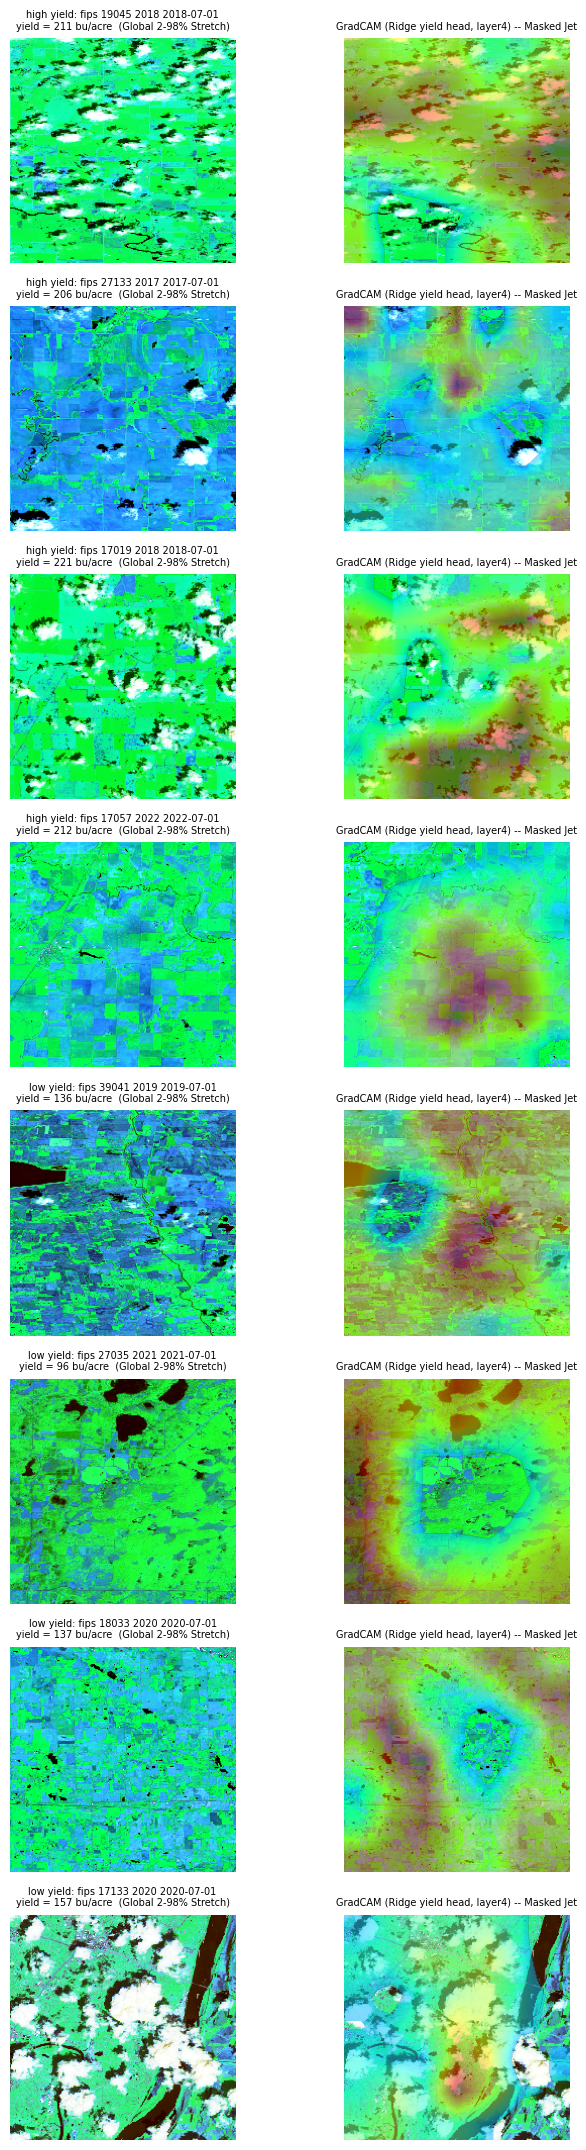


Saved d:\OneDrive - Yale University\Academics\AMTH 5520\Final Project\project-geospatial\results\charts\gradcam_examples.png


In [62]:
"""
GradCAM tiles in Sentinel-2 *agriculture* false colour (SWIR1 R, NIR G, Blue B).

Bands stored in feature_index/h5 are channel 0 = B02 Blue, channel 1 = B08 NIR, channel 2 = B11 SWIR1.
Standard agriculture false color is (R, G, B) = (SWIR1, NIR, Blue).

Tile rendering: a global 2nd-98th percentile stretch over the whole RGB array (not per-band) --
auto-balances contrast on each tile without amplifying uint8 quantization noise into per-band
artifacts and without relying on a brittle hardcoded brightness multiplier.

Heatmap overlay: numpy-masked standard `jet` at alpha=0.5. Values below 0.3 are masked out
(fully transparent), so only the high-attention regions get colored; the cold low-end of jet
never tints the agriculture-FC background.
"""
if regressor is None:
    print("[GradCAM] regressor is None (encoder weights missing) -- skipping heatmaps.")
else:
    N_HIGH = cfg.GRADCAM_N_HIGH
    N_LOW  = cfg.GRADCAM_N_LOW

    labeled = pcy.dropna(subset=["corn_yield"]).copy()
    labeled["bin"] = pd.qcut(labeled["corn_yield"], q=5, labels=False, duplicates="drop")
    high = labeled[labeled["bin"] == labeled["bin"].max()].sample(N_HIGH, random_state=cfg.SEED)
    low  = labeled[labeled["bin"] == labeled["bin"].min()].sample(N_LOW,  random_state=cfg.SEED + 1)
    target_county_years = pd.concat(
        [high.assign(label="high yield"), low.assign(label="low yield")],
        ignore_index=True,
    )

    fi_local = pd.read_parquet(FEATURE_INDEX_PATH)
    sample_records = []
    for _, row in target_county_years.iterrows():
        cand = fi_local[(fi_local["fips"] == row["fips"]) & (fi_local["year"] == row["year"])]
        if len(cand) == 0:
            continue
        mid = cand.iloc[len(cand) // 2]
        sample_records.append(dict(
            fips=int(row["fips"]), year=int(row["year"]),
            biweek=str(mid["biweek"]), grid_idx=int(mid["grid_idx"]),
            h5_path=str(mid["h5_path"]), label=str(row["label"]),
            corn_yield=float(row["corn_yield"]),
        ))
    print(f"Selected {len(sample_records)} tiles for GradCAM (yield-target).")

    def load_tile(rec):
        with h5py.File(DATA_RAW / rec["h5_path"], "r", rdcc_nbytes=0) as f:
            return np.array(f[str(rec["fips"])][rec["biweek"]]["data"][rec["grid_idx"]], copy=True)

    def preprocess(tile_uint8: np.ndarray) -> torch.Tensor:
        x = torch.from_numpy(tile_uint8).permute(2, 0, 1).float().unsqueeze(0) / 255.0
        return (x - GS_MEAN) / GS_STD

    def agriculture_false_color_simple(tile_uint8: np.ndarray) -> np.ndarray:
        """Reorder to SWIR1, NIR, Blue and apply a global 2nd-98th percentile stretch
        over the whole RGB array (not per-band). Auto-balances per-tile contrast without
        relying on hardcoded multipliers and without per-band ratio distortion.
        """
        rgb = tile_uint8[..., (2, 1, 0)].astype(np.float32)
        p_low, p_high = np.percentile(rgb, (2, 98))
        return np.clip((rgb - p_low) / (p_high - p_low + 1e-8), 0, 1)

    gc_yield = LayerGradCam(regressor, regressor.backbone.layer4[-1])

    n_show = len(sample_records)
    fig, axes = plt.subplots(n_show, 2, figsize=(7.8, 2.7 * n_show))
    if n_show == 1:
        axes = axes.reshape(1, -1)

    for i, rec in enumerate(sample_records):
        tile = load_tile(rec)
        x = preprocess(tile).to(DEVICE)
        x.requires_grad_(True)

        cam = gc_yield.attribute(x).cpu().detach().numpy()[0, 0]
        cam_up = LayerAttribution.interpolate(
            torch.tensor(cam).unsqueeze(0).unsqueeze(0), (224, 224), interpolate_mode="bilinear",
        ).numpy()[0, 0]
        cam_up = (cam_up - cam_up.min()) / (cam_up.max() - cam_up.min() + 1e-8)

        # Mask the bottom 30% of attention so only high-attention areas overlay the tile.
        cam_masked = np.ma.masked_where(cam_up < 0.3, cam_up)

        rgb = agriculture_false_color_simple(tile)

        ax = axes[i, 0]
        ax.imshow(rgb)
        ax.set_title(
            f"{rec['label']}: fips {rec['fips']} {rec['year']} {rec['biweek']}\n"
            f"yield = {rec['corn_yield']:.0f} bu/acre  (Global 2-98% Stretch)",
            fontsize=7,
        )
        ax.axis("off")

        ax = axes[i, 1]
        ax.imshow(rgb)
        ax.imshow(cam_masked, cmap="jet", alpha=0.5, vmin=0, vmax=1)
        ax.set_title("GradCAM (Ridge yield head, layer4) -- Masked Jet", fontsize=7)
        ax.axis("off")

    plt.tight_layout()
    plt.savefig(GRADCAM_PATH, dpi=130, bbox_inches="tight")
    plt.show()
    print(f"\nSaved {GRADCAM_PATH}")


## 7. Plain PHATE — included for completeness

We also run plain PHATE (Moon et al., *Nat. Biotechnol.* 2019) on the same L2-normed feature matrix as a sanity check. Unlike M-PHATE in Section 3, plain PHATE does not have an interslice kernel, so it has no inductive bias toward smooth temporal trajectories — it just sees the ~44 k points in 512-d. Given the dimensional-collapse finding from Section 2 we expect, and find, a ball-shaped 2-D embedding with significant state and biweek mixing. We use library defaults (no PCA-whitening, no per-county centring, no $t$-sweep): the goal is not to coax a result out of plain PHATE, only to show what it produces on the current encoder.


[PHATE] fitting (this is the slow one: ~few minutes on full data)...
    SGD-MDS may not have converged: stress changed by 1.8% in final iterations. Consider increasing n_iter or adjusting learning_rate.
[PHATE] done in 21.9s, output shape (44140, 2)


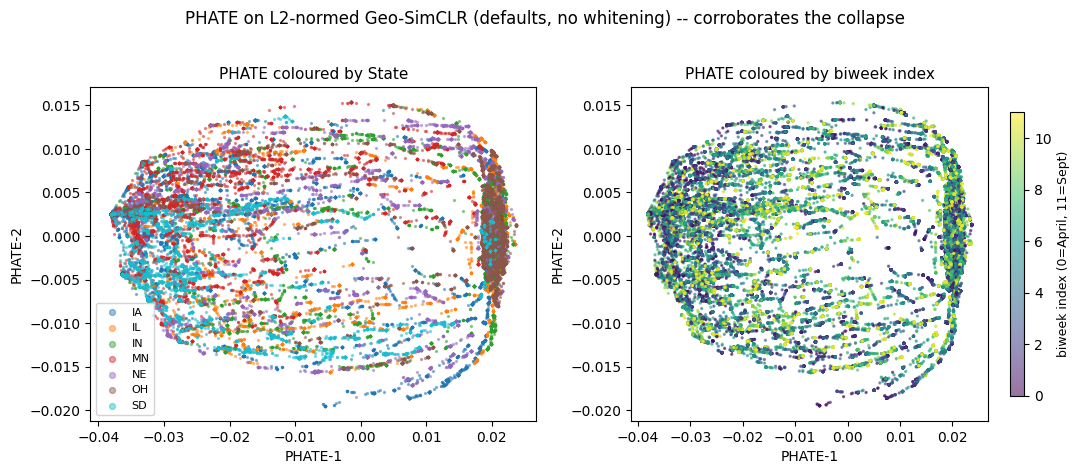


Saved d:\OneDrive - Yale University\Academics\AMTH 5520\Final Project\project-geospatial\results\charts\phate_collapse.png


In [63]:
"""
Plain PHATE on the L2-normalised biweekly feature matrix.
"""
try:
    import phate as _phate_lib
except ImportError:
    print("[PHATE] `phate` not installed -- skipping. (pip install phate)")
else:
    print("[PHATE] fitting (this is the slow one: ~few minutes on full data)...")
    t0 = time.time()
    phate_op = _phate_lib.PHATE(n_components=2, knn=5, t="auto", random_state=cfg.SEED, verbose=0)
    phate_2d = phate_op.fit_transform(X)
    print(f"[PHATE] done in {time.time() - t0:.1f}s, output shape {phate_2d.shape}")

    df["phate_1"] = phate_2d[:, 0]
    df["phate_2"] = phate_2d[:, 1]

    fig, axes = plt.subplots(1, 2, figsize=(11, 4.6))
    ax = axes[0]
    for s in cfg.EVAL_STATES:
        sub = df[df["state"] == s]
        ax.scatter(sub["phate_1"], sub["phate_2"], s=2, alpha=0.45,
                   c=STATE_PALETTE[s], label=s, rasterized=True)
    ax.legend(loc="best", fontsize=8, markerscale=3, framealpha=0.85)
    ax.set_title("PHATE coloured by State", fontsize=11)
    ax.set_xlabel("PHATE-1"); ax.set_ylabel("PHATE-2")

    ax = axes[1]
    sc = ax.scatter(df["phate_1"], df["phate_2"], s=2, alpha=0.55,
                    c=df["biweek_idx"], cmap="viridis", vmin=0, vmax=11, rasterized=True)
    cbar = plt.colorbar(sc, ax=ax, ticks=range(0, 12, 2), shrink=0.85)
    cbar.set_label("biweek index (0=April, 11=Sept)", fontsize=9)
    ax.set_title("PHATE coloured by biweek index", fontsize=11)
    ax.set_xlabel("PHATE-1"); ax.set_ylabel("PHATE-2")

    fig.suptitle("PHATE on L2-normed Geo-SimCLR (defaults, no whitening) -- corroborates the collapse",
                 fontsize=12, y=1.02)
    plt.tight_layout()
    plt.savefig(PHATE_PATH, dpi=130, bbox_inches="tight")
    plt.show()
    print(f"\nSaved {PHATE_PATH}")


## 8. Discussion, limitations, and next steps

### 8.1 What this notebook supports for the report

Geo-SimCLR is the strongest single-encoder model on both probe splits in notebook 05 (time-split Ridge $R^2 = +0.669$, county-split LightGBM $R^2 = +0.660$), beating every foundation-model frozen baseline and the supervised end-to-end ConvLSTM. The visualisations above tell us *what* the model learned to make those numbers possible:

- **Section 3 (M-PHATE, year-averaged).** The state colouring shows clean state-coherent clusters in the 2-D embedding — the strongest single piece of evidence that the encoder learned meaningful agro-climatic / geographic identity. The biweek colouring shows smooth-but-tightly-overlapping seasonal transitions; that smoothness is partly the encoder having learned phenology and partly M-PHATE's interslice kernel imposing temporal coherence by construction, so the residual biweek spread is a **generous upper bound** on the encoder's own phenology signal.
- **Section 4 (UMAP).** A library-default sanity check on the same L2-normalised matrix. Geographic structure is present but heavily intermixed — consistent with the manifold being too dense for UMAP's local-distance focus to find clean state boundaries on its own. (M-PHATE's interslice kernel does the right thing for our data; UMAP does not have an analogous bias.)
- **Section 5 (PCA per-county trajectories).** Each picked county's 12 biweek points span only a small fraction of the global pairwise distance in 2-D PCA — the visual demonstration that the seasonal phenology trajectory is not well encoded. A county imaged in early April and the same county imaged in mid September map to nearly the same point, which is the hallmark of dimensional collapse onto static county identity.
- **Section 6 (GradCAM).** The encoder pulls its yield signal from cropland-vs-non-cropland regions of each tile (rivers, urban areas, and non-arable boundaries are de-emphasised). Given the collapse finding these should be read as *static-feature attributions*, not as a per-pixel readout of crop growth.
- **Section 7 (plain PHATE).** Without M-PHATE's interslice kernel plain PHATE collapses onto a ball with significant state and biweek mixing — visual corroboration of the SVD-based collapse evidence in Section 2.

### 8.2 The dimensional-collapse limitation — in plain language

Contrastive losses like NT-Xent want the encoder to distinguish anchors from negatives. If the positive pairs are *too easy* — which is what happens here, because two views of the same county two weeks apart at 9 km / ~40 m-per-pixel are intrinsically very similar — the encoder can satisfy the loss by picking up a relatively small number of "this is county X" features and underweighting everything else. Jing et al.\ (2022, *Understanding Dimensional Collapse in Contrastive Self-supervised Learning*) characterise exactly this failure mode. Our diagnostics in Section 2 measure the symptoms on the current feature matrix: an effective rank well below the 512 embedding dimension, top-K variance concentrated in a small number of leading PCs, and a post-L2 cosine-similarity distribution shifted positive instead of centred on zero.

This is consistent with what is visible across the figures: the yield probes work because tree- and Ridge-based heads can extract a useful signal even from a low-rank space; M-PHATE recovers clean geographic clusters because that geographic identity is exactly what the SSL objective ended up encoding; but plain 2-D PHATE / UMAP and the per-county PCA trajectories show the collapse plainly.

### 8.3 Concrete next-step fixes

These belong in the future-work section of the report, not in this submission:

1. **Decorrelation regulariser.** Adding a Barlow-Twins (Zbontar et al.\ 2021) or VICReg (Bardes et al.\ 2022) off-diagonal cross-correlation term on top of NT-Xent is a ten-line change and the most direct fix for collapse — it is the planned fallback if more compute becomes available.
2. **Harder positives.** The current positive pair is biweek $t$ matched with $t \pm 1$. Increasing the temporal gap to $\pm 3$ or $\pm 5$ biweeks makes the pair task non-trivial (early-season bare soil vs. mid-season closed canopy at the same field).
3. **Stronger spatial augmentations.** Smaller crops, more aggressive scale jitter, and optional channel-mixing within the AG band set (Blue / NIR / SWIR1) would force the encoder to use more of its capacity.
4. **4-channel AG + NDVI input.** Adding a proper NDVI channel (computed from B04 and B08, as we do in notebook 03) gives the encoder a phenology-explicit signal, possibly preventing it from collapsing onto static county identity in the first place.
5. **Same-county-within-biweek positive ablation.** Tests whether spatial positives help county-level yield prediction — *complementary* in spirit to (2), not a replacement.

### 8.4 Outputs from this notebook

| File | Description |
|------|-------------|
| `data/processed/features/per_county_year_biweek/geo_simclr_resnet18.parquet` | per-(state, fips, year, biweek) Geo-SimCLR features (raw mean-pooled; L2-normalised at use time) |
| `results/tables/effective_rank.parquet` | dimensional-collapse diagnostics (effective rank, top-K variance, within / between-county variance, cosine-similarity distribution) |
| `results/charts/singular_spectrum.png` | top-50 singular values of the L2-normalised feature matrix |
| `results/charts/m_phate_collapse.png` | year-averaged M-PHATE two-panel (biweek, state) — the headline geographic-structure figure |
| `results/charts/umap_facets.png` | three-panel UMAP coloured by state, CRD, and yield quintile |
| `results/charts/pca_county_trajectories.png` | 2-D PCA with biweek trajectories of 3-4 representative counties — visual collapse demonstration |
| `results/charts/gradcam_examples.png` | GradCAM overlays in agriculture false colour with the masked-`jet` heatmap |
| `results/charts/phate_collapse.png` | plain PHATE two-panel (state, biweek) — corroborates the collapse |
